# Capstone Project 4: Sales Forecasting

## Objective

The objective of this project is to analyze historical sales data and build a machine learning model to forecast future sales.

The project demonstrates data preprocessing, exploratory data analysis, feature engineering, model training, evaluation, and business insights.

# Business Problem

Businesses rely on accurate sales forecasts to manage inventory, optimize operations, and improve financial planning.

Machine learning can identify sales patterns and predict future sales based on historical data.

# Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Train-Test Split
7. Model Training
8. Model Evaluation
9. Business Insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

%matplotlib inline

In [2]:
df = pd.read_csv("../data/train.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [5]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


# Dataset Overview

The dataset contains historical sales information.

The target variable is **Sales**, and the remaining columns are used to predict future sales.

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [7]:
for column in df.select_dtypes(include="number").columns:
    df[column] = df[column].fillna(df[column].median())

In [8]:
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [9]:
df = pd.get_dummies(df, drop_first=True)

In [10]:
df.head()

,Row ID,Postal Code,Sales,Order ID_CA-2015-100090,Order ID_CA-2015-100293,Order ID_CA-2015-100328,Order ID_CA-2015-100363,Order ID_CA-2015-100391,Order ID_CA-2015-100678,Order ID_CA-2015-100706,...,Product Name_Zebra ZM400 Thermal Label Printer,Product Name_Zebra Zazzle Fluorescent Highlighters,Product Name_Zipper Ring Binder Pockets,Product Name_i.Sound Portable Power - 8000 mAh,Product Name_iHome FM Clock Radio with Lightning Dock,"Product Name_iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",Product Name_iOttie HLCRIO102 Car Mount,Product Name_iOttie XL Car Mount,Product Name_invisibleSHIELD by ZAGG Smudge-Free Screen Protector,Product Name_netTALK DUO VoIP Telephone Service
0,1,42420.0,261.9600,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,42420.0,731.9400,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,90036.0,14.6200,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,33311.0,957.5775,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,33311.0,22.3680,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [11]:
X = df.drop("Sales", axis=1)

y = df["Sales"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print(X_train.shape)

print(X_test.shape)

(7840, 13371)
(1960, 13371)


# Model Training

A Random Forest Regressor is trained to predict future sales based on historical data.

In [14]:
model = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    max_depth=10
)

In [15]:
model.fit(X_train, y_train)

,n_estimators,20
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred = model.predict(X_test)

# Model Evaluation

The forecasting model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [17]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

MAE  : 221.52
MSE  : 509625.58
RMSE : 713.88
R² Score : 0.2375


In [18]:
results = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred
})

results.head()

,Actual Sales,Predicted Sales
532,47.94,81.166302
872,11.36,68.610360
1149,10.95,339.460127
2287,17.48,68.610360
4038,21.12,68.610360


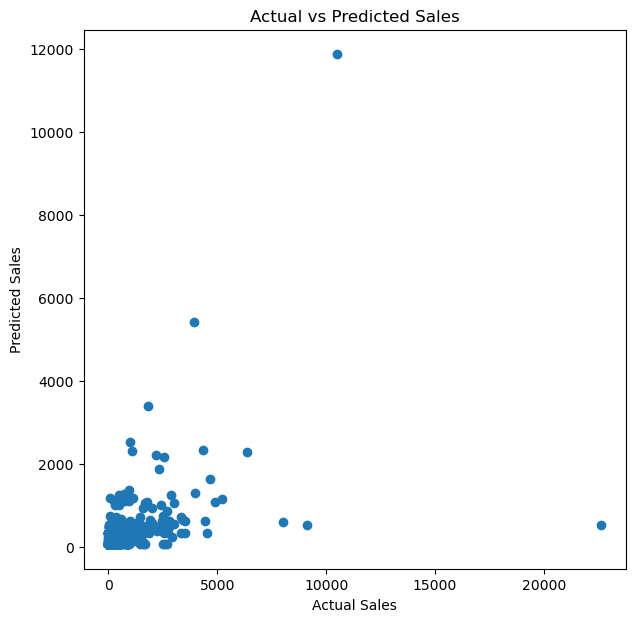

In [19]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# Business Insights

The forecasting model can estimate future sales using historical business data.

The model can help businesses:

- Improve inventory planning
- Support demand forecasting
- Optimize stock management
- Improve financial planning

# Conclusion

This project demonstrated an end-to-end sales forecasting workflow using machine learning.

The workflow included:

- Data Cleaning
- Feature Engineering
- Model Training
- Model Evaluation
- Business Interpretation

The trained model can support better business planning through accurate sales predictions.

In [20]:
results.to_csv(
    "../outputs/sales_predictions.csv",
    index=False
)

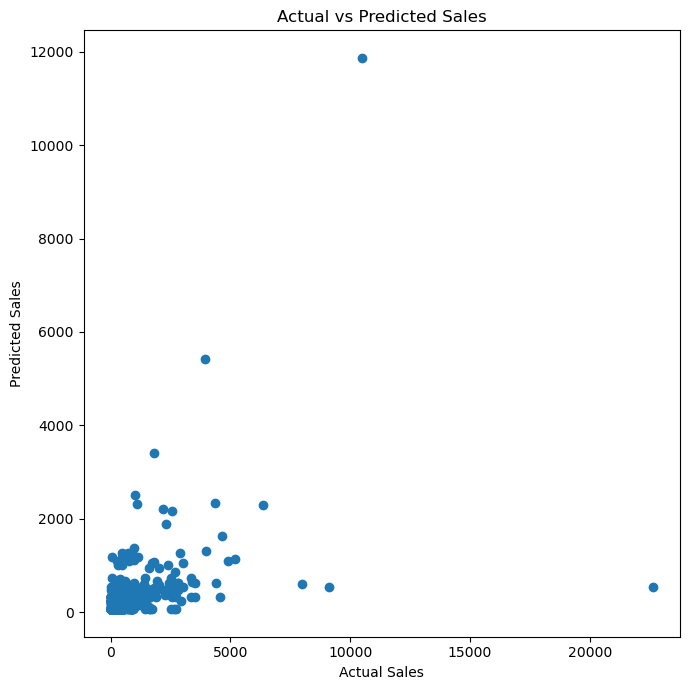

In [21]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.tight_layout()

plt.savefig("../images/sales_prediction.png")

plt.show()